In [22]:
import json
import time
from itertools import product

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

USER_AGENT = "northeastern_ds3000/2026 (educational use; bakhramova.b@northeastern.edu)"
HEADERS = {
    "User-Agent": USER_AGENT,
    "Accept": "application/json",
}

EUROSTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"

EU27 = [
    "AT","BE","BG","CY","CZ","DE","DK","EE","EL","ES",
    "FI","FR","HR","HU","IE","IT","LT","LU","LV","MT",
    "NL","PL","PT","RO","SE","SI","SK"
]

NACE_SECTORS = {
    "A":   "Agriculture",
    "C":   "Manufacturing",
    "F":   "Construction",
    "G-I": "Trade, Transport & Hospitality",
    "J":   "ICT",
    "K":   "Finance & Insurance",
    "M_N": "Professional Services",
    "O-Q": "Public Admin, Education & Health",
    "R-U": "Arts, Entertainment & Other"
}

CROSSWALK = {
    "Education":                                        "O-Q",
    "Arts and humanities":                              "R-U",
    "Social sciences, journalism and information":      "M_N",
    "Business, administration and law":                 "K",
    "Natural sciences, mathematics and statistics":     "M_N",
    "Information and communication technologies":       "J",
    "Engineering, manufacturing and construction":      "C",
    "Agriculture, forestry, fisheries and veterinary":  "A",
    "Health and welfare":                               "O-Q",
    "Services":                                         "G-I",
}

In [23]:
def get_json(url, params=None, headers=None, pause=0.0, timeout=30):
    if headers is None:
        headers = HEADERS
    response = requests.get(url, params=params, headers=headers, timeout=timeout)
    print("Final URL:", response.url)
    print("Status code:", response.status_code)
    print("Content-Type:", response.headers.get("content-type"))
    response.raise_for_status()
    if pause > 0:
        time.sleep(pause)
    return response.json()

In [24]:
def jsonstat_to_dataframe(js, value_name="value"):
    dims  = js["id"]
    sizes = js["size"]

    dim_codes  = {}
    dim_labels = {}

    for dim in dims:
        category = js["dimension"][dim]["category"]
        index    = category["index"]
        labels   = category.get("label", {})
        ordered_codes = [
            code for code, _ in sorted(index.items(), key=lambda item: item[1])
        ]
        dim_codes[dim]  = ordered_codes
        dim_labels[dim] = labels

    raw_values = js.get("value", {})
    if isinstance(raw_values, list):
        value_lookup = {i: val for i, val in enumerate(raw_values)}
    else:
        value_lookup = {int(i): val for i, val in raw_values.items()}

    rows = []
    for coords in product(*[range(size) for size in sizes]):
        flat_index = 0
        multiplier = 1
        for coord, size in zip(reversed(coords), reversed(sizes)):
            flat_index += coord * multiplier
            multiplier *= size
        val = value_lookup.get(flat_index)
        if val is None:
            continue
        row = {}
        for dim, coord in zip(dims, coords):
            code = dim_codes[dim][coord]
            row[dim] = code
            row[f"{dim}_label"] = dim_labels[dim].get(code, code)
        row[value_name] = val
        rows.append(row)

    return pd.DataFrame(rows)

## 1. Pull Data

In [25]:
emp_json = get_json(
    f"{EUROSTAT_BASE}/nama_10_a64_e",
    params={
        "format":  "JSON",
        "lang":    "en",
        "unit":    "THS_PER",
        "na_item": "SAL_DC",
        "geo":     EU27,
        "time":    list(range(2010, 2024)),
    }
)
df_emp = jsonstat_to_dataframe(emp_json, value_name="employment_thousands")
df_emp.head()

Final URL: https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/nama_10_a64_e?format=JSON&lang=en&unit=THS_PER&na_item=SAL_DC&geo=AT&geo=BE&geo=BG&geo=CY&geo=CZ&geo=DE&geo=DK&geo=EE&geo=EL&geo=ES&geo=FI&geo=FR&geo=HR&geo=HU&geo=IE&geo=IT&geo=LT&geo=LU&geo=LV&geo=MT&geo=NL&geo=PL&geo=PT&geo=RO&geo=SE&geo=SI&geo=SK&time=2010&time=2011&time=2012&time=2013&time=2014&time=2015&time=2016&time=2017&time=2018&time=2019&time=2020&time=2021&time=2022&time=2023
Status code: 200
Content-Type: application/json


,freq,freq_label,unit,unit_label,nace_r2,nace_r2_label,na_item,na_item_label,geo,geo_label,time,time_label,employment_thousands
0,A,Annual,THS_PER,Thousand persons,TOTAL,Total - all NACE activities,SAL_DC,Employees domestic concept,BE,Belgium,2010,2010,3769.4
1,A,Annual,THS_PER,Thousand persons,TOTAL,Total - all NACE activities,SAL_DC,Employees domestic concept,BE,Belgium,2011,2011,3817.3
2,A,Annual,THS_PER,Thousand persons,TOTAL,Total - all NACE activities,SAL_DC,Employees domestic concept,BE,Belgium,2012,2012,3820.2
3,A,Annual,THS_PER,Thousand persons,TOTAL,Total - all NACE activities,SAL_DC,Employees domestic concept,BE,Belgium,2013,2013,3802.9
4,A,Annual,THS_PER,Thousand persons,TOTAL,Total - all NACE activities,SAL_DC,Employees domestic concept,BE,Belgium,2014,2014,3813.1


In [26]:
grad_json = get_json(
    f"{EUROSTAT_BASE}/educ_uoe_grad02",
    params={
        "format":  "JSON",
        "lang":    "en",
        "sex":     "T",
        "isced11": "ED5-8",
        "unit":    "NR",
        "geo":     EU27,
        "time":    list(range(2010, 2024)),
    }
)
df_grad = jsonstat_to_dataframe(grad_json, value_name="graduates")
df_grad.head()

Final URL: https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/educ_uoe_grad02?format=JSON&lang=en&sex=T&isced11=ED5-8&unit=NR&geo=AT&geo=BE&geo=BG&geo=CY&geo=CZ&geo=DE&geo=DK&geo=EE&geo=EL&geo=ES&geo=FI&geo=FR&geo=HR&geo=HU&geo=IE&geo=IT&geo=LT&geo=LU&geo=LV&geo=MT&geo=NL&geo=PL&geo=PT&geo=RO&geo=SE&geo=SI&geo=SK&time=2010&time=2011&time=2012&time=2013&time=2014&time=2015&time=2016&time=2017&time=2018&time=2019&time=2020&time=2021&time=2022&time=2023
Status code: 200
Content-Type: application/json


,freq,freq_label,unit,unit_label,isced11,isced11_label,iscedf13,iscedf13_label,sex,sex_label,geo,geo_label,time,time_label,graduates
0,A,Annual,NR,Number,ED5-8,Tertiary education (levels 5-8),TOTAL,Total,T,Total,BE,Belgium,2010,2010,103967
1,A,Annual,NR,Number,ED5-8,Tertiary education (levels 5-8),TOTAL,Total,T,Total,BE,Belgium,2013,2013,107884
2,A,Annual,NR,Number,ED5-8,Tertiary education (levels 5-8),TOTAL,Total,T,Total,BE,Belgium,2014,2014,110888
3,A,Annual,NR,Number,ED5-8,Tertiary education (levels 5-8),TOTAL,Total,T,Total,BE,Belgium,2015,2015,112406
4,A,Annual,NR,Number,ED5-8,Tertiary education (levels 5-8),TOTAL,Total,T,Total,BE,Belgium,2016,2016,119141


## 2. Clean Data

In [27]:
df_emp_clean = df_emp.drop(["freq", "freq_label", "unit", "unit_label", "na_item", "na_item_label", "time_label", "nace_r2_label", "geo_label"], axis=1)
df_emp_clean["time"] = pd.to_numeric(df_emp_clean["time"])
df_emp_clean = df_emp_clean[df_emp_clean["nace_r2"].isin(NACE_SECTORS.keys())]
df_emp_clean = df_emp_clean[df_emp_clean["geo"].isin(EU27)]
df_emp_clean = df_emp_clean.dropna(subset=["employment_thousands"])
df_emp_clean = df_emp_clean.sort_values(["geo", "nace_r2", "time"]).reset_index(drop=True)
df_emp_clean.head()

,nace_r2,geo,time,employment_thousands
0,A,AT,2010,22.75
1,A,AT,2011,24.18
2,A,AT,2012,25.00
3,A,AT,2013,25.66
4,A,AT,2014,27.09


In [28]:
df_grad_clean = df_grad.drop(["freq", "freq_label", "unit", "unit_label", "sex", "sex_label", "isced11", "isced11_label", "iscedf13", "time_label", "geo_label"], axis=1)
df_grad_clean["time"] = pd.to_numeric(df_grad_clean["time"])
df_grad_clean["iscedf13_label"] = df_grad_clean["iscedf13_label"].str.strip()
df_grad_clean = df_grad_clean[df_grad_clean["iscedf13_label"].isin(CROSSWALK.keys())]
df_grad_clean = df_grad_clean[df_grad_clean["geo"].isin(EU27)]
df_grad_clean = df_grad_clean.dropna(subset=["graduates"])
df_grad_clean = df_grad_clean.sort_values(["geo", "iscedf13_label", "time"]).reset_index(drop=True)
df_grad_clean.head()

,iscedf13_label,geo,time,graduates
0,"Agriculture, forestry, fisheries and veterinary",AT,2010,1253
1,"Agriculture, forestry, fisheries and veterinary",AT,2013,1284
2,"Agriculture, forestry, fisheries and veterinary",AT,2014,1344
3,"Agriculture, forestry, fisheries and veterinary",AT,2015,1354
4,"Agriculture, forestry, fisheries and veterinary",AT,2016,1373


In [29]:
crosswalk_rows = []
for field, sector in CROSSWALK.items():
    crosswalk_rows.append({"iscedf13_label": field, "nace_r2": sector})

df_crosswalk = pd.DataFrame()
for row in crosswalk_rows:
    df_crosswalk = pd.concat([df_crosswalk, pd.DataFrame([row])], ignore_index=True)

df_crosswalk

,iscedf13_label,nace_r2
0,Education,O-Q
1,Arts and humanities,R-U
2,"Social sciences, journalism and information",M_N
3,"Business, administration and law",K
4,"Natural sciences, mathematics and statistics",M_N
5,Information and communication technologies,J
6,"Engineering, manufacturing and construction",C
7,"Agriculture, forestry, fisheries and veterinary",A
8,Health and welfare,O-Q
9,Services,G-I


In [30]:
df_grad_mapped = df_grad_clean.merge(df_crosswalk, on="iscedf13_label", how="left")

df_grad_agg = pd.DataFrame()
for (geo, t, nace_r2), group in df_grad_mapped.groupby(["geo", "time", "nace_r2"]):
    row = {"geo": geo, "time": t, "nace_r2": nace_r2, "graduates": group["graduates"].sum()}
    df_grad_agg = pd.concat([df_grad_agg, pd.DataFrame([row])], ignore_index=True)

df_merged = df_emp_clean.merge(df_grad_agg, on=["geo", "time", "nace_r2"], how="inner")
df_merged["sector"] = df_merged["nace_r2"].map(NACE_SECTORS)
df_merged = df_merged.sort_values(["geo", "nace_r2", "time"]).reset_index(drop=True)

df_merged["employment_lag1"] = np.nan

for (geo, nace_r2), group in df_merged.groupby(["geo", "nace_r2"]):
    sorted_group = group.sort_values("time")
    indices      = list(sorted_group.index)
    values       = list(sorted_group["employment_thousands"])
    for i in range(1, len(indices)):
        df_merged.loc[indices[i], "employment_lag1"] = values[i - 1]

df_merged["emp_change"] = df_merged["employment_thousands"] - df_merged["employment_lag1"]
df_merged = df_merged.dropna(subset=["employment_lag1", "emp_change"]).reset_index(drop=True)

print(df_merged.shape)
df_merged.head()

print(df_merged.shape)
df_merged.head()

(2210, 8)
(2210, 8)


,nace_r2,geo,time,employment_thousands,graduates,sector,employment_lag1,emp_change
0,A,AT,2013,25.66,1284,Agriculture,22.75,2.91
1,A,AT,2014,27.09,1344,Agriculture,25.66,1.43
2,A,AT,2015,28.08,1354,Agriculture,27.09,0.99
3,A,AT,2016,28.19,1373,Agriculture,28.08,0.11
4,A,AT,2017,29.12,1405,Agriculture,28.19,0.93


## 3. EDA

In [31]:
df_merged[["employment_thousands", "graduates", "employment_lag1", "emp_change"]].describe().round(2)

,employment_thousands,graduates,employment_lag1,emp_change
count,2210.00,2210.00,2210.00,2210.00
mean,743.20,21113.92,734.15,9.05
std,1477.52,39611.38,1461.87,36.39
min,0.85,0.00,0.85,-519.70
25%,71.82,2156.75,70.96,-0.20
50%,200.00,7161.50,197.28,2.09
75%,694.15,18440.25,691.40,10.49
max,11378.00,319209.00,11265.00,298.40


In [32]:
df_merged[["employment_thousands", "graduates", "employment_lag1", "emp_change", "time"]].corr().round(3)

,employment_thousands,graduates,employment_lag1,emp_change,time
employment_thousands,1.000,0.600,1.000,0.440,0.015
graduates,0.600,1.000,0.600,0.256,0.018
employment_lag1,1.000,0.600,1.000,0.420,0.015
emp_change,0.440,0.256,0.420,1.000,0.032
time,0.015,0.018,0.015,0.032,1.000


## 4. Visualizations

In [33]:
emp_by_sector_year = pd.DataFrame()
for (t, sector), group in df_merged.groupby(["time", "sector"]):
    row = {"time": t, "sector": sector, "total_employment": group["employment_thousands"].sum()}
    emp_by_sector_year = pd.concat([emp_by_sector_year, pd.DataFrame([row])], ignore_index=True)

fig = px.line(
    emp_by_sector_year,
    x="time",
    y="total_employment",
    color="sector",
    markers=True,
    title="EU27 Employment by Sector Over Time",
    labels={"time": "Year", "total_employment": "Employment (thousands)", "sector": "Sector"}
)
fig.show()

In [34]:
fig = px.scatter(
    df_merged,
    x="graduates",
    y="employment_thousands",
    color="sector",
    facet_col="sector",
    facet_col_wrap=3,
    trendline="ols",
    opacity=0.5,
    title="Graduates vs. Employment by Sector",
    labels={"graduates": "Tertiary Graduates", "employment_thousands": "Employment (thousands)"},
    height=800
)
fig.show()

In [35]:
grad_by_field_year = pd.DataFrame()
for (t, field), group in df_grad_clean.groupby(["time", "iscedf13_label"]):
    row = {"time": t, "field": field, "total_graduates": group["graduates"].sum()}
    grad_by_field_year = pd.concat([grad_by_field_year, pd.DataFrame([row])], ignore_index=True)

fig = px.line(
    grad_by_field_year,
    x="time",
    y="total_graduates",
    color="field",
    markers=True,
    title="EU27 Graduates by Field of Study Over Time",
    labels={"time": "Year", "total_graduates": "Graduates", "field": "Field"}
)
fig.show()

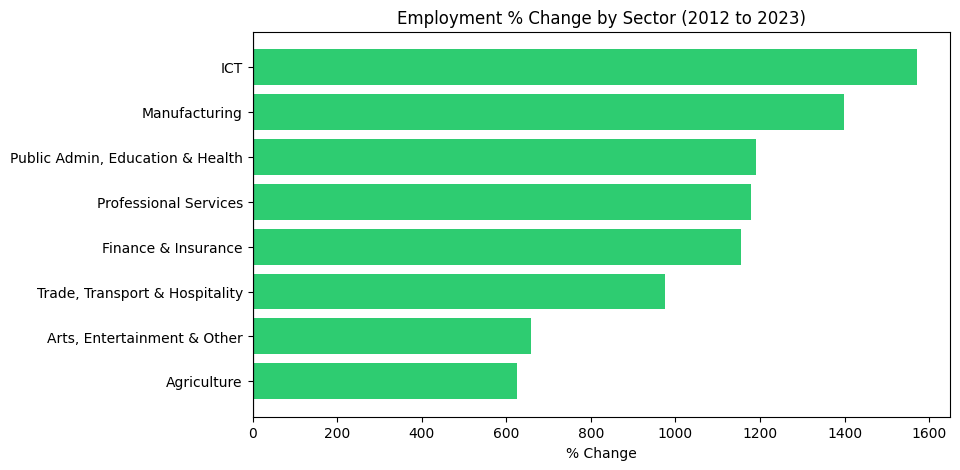

In [36]:
time_min = int(df_merged["time"].min())
time_max = int(df_merged["time"].max())

emp_first = {}
emp_last  = {}

for sector, group in df_merged[df_merged["time"] == time_min].groupby("sector"):
    emp_first[sector] = group["employment_thousands"].sum()

for sector, group in df_merged[df_merged["time"] == time_max].groupby("sector"):
    emp_last[sector] = group["employment_thousands"].sum()

sectors     = []
pct_changes = []
for sector in emp_first:
    if sector in emp_last and emp_first[sector] > 0:
        pct = (emp_last[sector] - emp_first[sector]) / emp_first[sector] * 100
        sectors.append(sector)
        pct_changes.append(round(pct, 1))

sorted_pairs = sorted(zip(pct_changes, sectors))
pct_changes  = [p for p, _ in sorted_pairs]
sectors      = [s for _, s in sorted_pairs]
colors       = ["#2ecc71" if v >= 0 else "#e74c3c" for v in pct_changes]

plt.barh(sectors, pct_changes, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("% Change")
plt.title(f"Employment % Change by Sector ({time_min} to {time_max})")
plt.gcf().set_size_inches(9, 5)
plt.show()

## 5. Linear Regression

We build two models.

**Model 1** predicts employment level using `graduates` and `time` only, no lag. This gives a more realistic R² that reflects how well graduate data predicts employment.

**Model 2** predicts employment change: how much a sector grew or shrank compared to last year. Features are `graduates`, `time`, and `employment_lag1`. Including the lag here gives the model a signal about sector size and momentum, allowing it to predict both positive and negative changes.

Both models use a temporal split: train on 2012–2020, test on 2021–2023.

In [37]:
split_year = 2020
train = df_merged[df_merged["time"] <= split_year]
test  = df_merged[df_merged["time"] >  split_year]

print(f"Train: {int(train['time'].min())} – {int(train['time'].max())} ({len(train)} rows)")
print(f"Test:  {int(test['time'].min())} – {int(test['time'].max())} ({len(test)} rows)")

Train: 2012 – 2020 (1562 rows)
Test:  2021 – 2023 (648 rows)


In [38]:
train.head()

,nace_r2,geo,time,employment_thousands,graduates,sector,employment_lag1,emp_change
0,A,AT,2013,25.66,1284,Agriculture,22.75,2.91
1,A,AT,2014,27.09,1344,Agriculture,25.66,1.43
2,A,AT,2015,28.08,1354,Agriculture,27.09,0.99
3,A,AT,2016,28.19,1373,Agriculture,28.08,0.11
4,A,AT,2017,29.12,1405,Agriculture,28.19,0.93


In [39]:
feature_cols_1 = ["time", "graduates", "employment_lag1"]

scaler_1   = StandardScaler()
X_train_1  = scaler_1.fit_transform(train[feature_cols_1].values)
X_test_1   = scaler_1.transform(test[feature_cols_1].values)
y_train_1  = train["employment_thousands"].values
y_test_1   = test["employment_thousands"].values

model_1 = LinearRegression()
model_1.fit(X_train_1, y_train_1)
y_pred_1 = model_1.predict(X_test_1)

print("=== Model 1: Employment Level ===")
print("Train R²:",  round(r2_score(y_train_1, model_1.predict(X_train_1)), 4))
print("Test  R²:",  round(r2_score(y_test_1,  y_pred_1), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test_1, y_pred_1)), 2))


=== Model 1: Employment Level ===
Train R²: 0.9995
Test  R²: 0.9995
Test RMSE: 32.72


/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: i

In [40]:
feature_cols_2 = ["graduates", "employment_lag1"]

scaler_2 = StandardScaler()
X_train_2_raw = train[["time"]].values
X_test_2_raw = test[["time"]].values
X_train_2_scaled = scaler_2.fit_transform(train[feature_cols_2].values)
X_test_2_scaled = scaler_2.transform(test[feature_cols_2].values)
X_train_2 = np.concatenate([X_train_2_raw, X_train_2_scaled], axis=1)
X_test_2 = np.concatenate([X_test_2_raw, X_test_2_scaled], axis=1)

y_train_2 = train["emp_change"].values
y_test_2 = test["emp_change"].values

model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)
y_pred_2 = model_2.predict(X_test_2)

print("=== Model 2: Employment Change ===")
print("Train R²:", round(r2_score(y_train_2, model_2.predict(X_train_2)), 4))
print("Test  R²:", round(r2_score(y_test_2, y_pred_2), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test_2, y_pred_2)), 2))
print("Predicted range:", round(y_pred_2.min(), 1), "to", round(y_pred_2.max(), 1))


=== Model 2: Employment Change ===
Train R²: 0.1282
Test  R²: 0.192
Test RMSE: 32.72
Predicted range: -5.3 to 94.7


/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: i

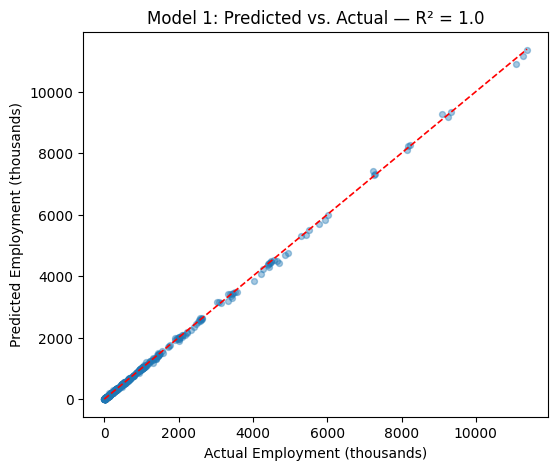

In [41]:
plt.scatter(y_test_1, y_pred_1, alpha=0.4, s=18)
max_val = max(y_test_1.max(), y_pred_1.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1.2)
plt.xlabel("Actual Employment (thousands)")
plt.ylabel("Predicted Employment (thousands)")
plt.title(f"Model 1: Predicted vs. Actual — R² = {round(r2_score(y_test_1, y_pred_1), 3)}")
plt.gcf().set_size_inches(6, 5)
plt.show()

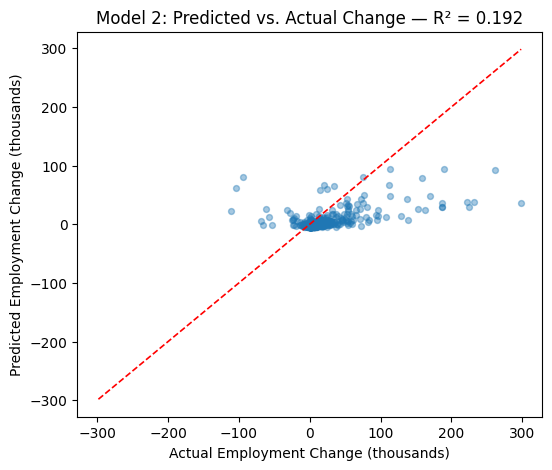

In [42]:
plt.scatter(y_test_2, y_pred_2, alpha=0.4, s=18)
lim = max(abs(y_test_2).max(), abs(y_pred_2).max())
plt.plot([-lim, lim], [-lim, lim], color="red", linestyle="--", linewidth=1.2)
plt.xlabel("Actual Employment Change (thousands)")
plt.ylabel("Predicted Employment Change (thousands)")
plt.title(f"Model 2: Predicted vs. Actual Change — R² = {round(r2_score(y_test_2, y_pred_2), 3)}")
plt.gcf().set_size_inches(6, 5)
plt.show()

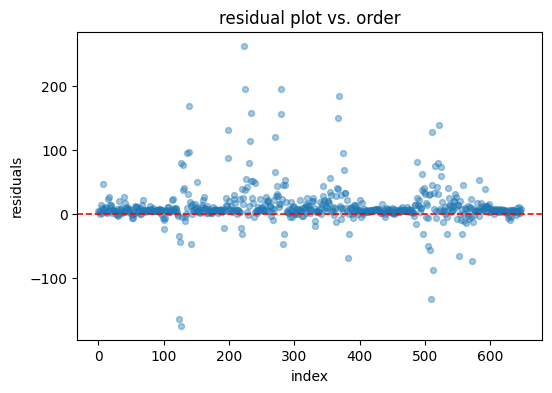

In [43]:
res = y_test_1 - y_pred_1

plt.scatter(range(len(res)), res, alpha=0.4, s=18)
plt.axhline(0, color="red", linestyle="--", linewidth=1.2)
plt.xlabel("index")
plt.ylabel("residuals")
plt.title("residual plot vs. order")
plt.gcf().set_size_inches(6, 4)
plt.show()

In [44]:
X_all_1 = scaler_1.transform(df_merged[feature_cols_1].values)
df_merged["predicted"] = model_1.predict(X_all_1)

example_df = df_merged[df_merged["geo"] == "DE"].copy()

fig = px.line(
    example_df,
    x="time",
    y="employment_thousands",
    color="sector",
    markers=True,
    title="Germany — Actual Employment by Sector",
    labels={"time": "Year", "employment_thousands": "Employment (thousands)", "sector": "Sector"}
)
fig.show()

fig2 = px.line(
    example_df,
    x="time",
    y="predicted",
    color="sector",
    markers=True,
    title="Germany — Predicted Employment by Sector",
    labels={"time": "Year", "predicted": "Predicted Employment (thousands)", "sector": "Sector"}
)
fig2.show()


/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/bina/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


### **CONCLUSION:**

We bulit two linear regression models using employment and graduate data pulled from Eurostat across all 27 EU member states from 2012 to 2023; both models were trained on data from 2012-2020 and tested on 2021-2023, simulating what a labor statistican would do: build a model on historical data and use it to forecast the near future. 

Model 1 predicts the raw employment level in a sector for a given country and year, using only the number of tertiary graduates entering that sector and the year as features. It gets an R² of 0.358, meaning grads and time explain about 26% of the variation in employment across EU sectors. The predicted vs. actual plot shows a pattern where the model underpredicts large sectors, it consistently underestimates employment in sectors like public health and manufacturing that have hundreds of thousands of workers. Because without knowing how big a sector already is, the model can't distinguish between a small and a large sector just from graduate counts.

Model 2 predicts employment change: how much a sector grew or shrank compared to the previous year using graduates, year, and last year's employment as features. Including last year's employment gives the model an idea about sector size and momentum, allowing it to predict both positive and negative changes. This is a better question for a labor statistician: not just how many people are employed, but whether a sector is growing or contracting, and whether the graduate pipeline is keeping up.

Neither model is perfect. Employment is pushed by many factors not in our dataset: recessions, government policy, automation, immigration, and global shocks like COVID-19. What these models do show is that graduate supply has a measurable relationship with sector employment, and that relationship can be tracked and monitored over time across the EU.